# 03 — Baseline Classifiers: Participant-Level Split

This notebook repeats the baseline classification from `02_baselines.ipynb` but uses a **participant-level (cross-subject) split** instead of a time-based split.

**Why this matters:** In the time-based split (notebook 02), the training and test sets contain windows from the *same* participants. The model can exploit person-specific patterns (e.g. participant p1's baseline pupil diameter) and achieves artificially high accuracy. A participant-level split evaluates whether the model generalises to **completely unseen individuals** — a much harder and more realistic scenario, and the one used in Jin et al. (2025).

**Split:** 17 participants for training, 4 participants for test (`random_state=42`)  
**Models:** Logistic Regression, SVM, Random Forest, KNN, XGBoost
**Tasks:** Rest vs Load | WM vs VA  
**Target to match:** SVM ~62% accuracy on WM vs VA (Jin et al., 2025)

## 1. Imports and Setup

In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
RESULTS = Path('../results/participant_split')
RESULTS.mkdir(exist_ok=True)

print('All imports OK.')

All imports OK.


## 2. Load Data and Define Features

Same 7 index features as in notebook 02.

In [5]:
with open('../data/features/features_512_511.pkl', 'rb') as f:
    df = pickle.load(f)

FEATURES = [
    'ipas', 'lhipas', 'fixation_nums', 'fixation_durations',
    'blink_rate', 'saccade_speeds', 'saccade_peak_speeds'
]

print('Dataset shape:', df.shape)
print('Total participants:', df['participant'].nunique())
print('Windows per participant:')
print(df['participant'].value_counts().sort_index().to_string())

Dataset shape: (347196, 18)
Total participants: 21
Windows per participant:
participant
p1     16534
p10    16357
p11    16394
p12    16611
p13    16517
p14    16542
p15    16628
p16    16601
p17    16367
p18    16580
p19    16608
p20    16442
p21    16584
p22    16607
p3     16543
p4     16615
p5     16399
p6     16577
p7     16496
p8     16574
p9     16620


## 3. Participant-Level Train/Test Split

We randomly select **4 participants** for the test set and use the remaining **17** for training.
`random_state=42` ensures the same split every time this notebook is run.

**Key property:** no window from a test participant ever appears in training. The scaler is fit *only* on training participants' data, so no test-set statistics leak into the preprocessing.

In [6]:
all_participants = sorted(df['participant'].unique())

rng = np.random.default_rng(42)
test_participants = list(rng.choice(all_participants, size=4, replace=False))
train_participants = [p for p in all_participants if p not in test_participants]

train_df = df[df['participant'].isin(train_participants)].copy()
test_df  = df[df['participant'].isin(test_participants)].copy()

print(f'Train participants ({len(train_participants)}): {sorted(train_participants)}')
print(f'Test  participants ({len(test_participants)}):  {sorted(test_participants)}')
print()
print(f'Train windows: {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Test  windows: {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%)')

Train participants (17): ['p1', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p19', 'p20', 'p21', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9']
Test  participants (4):  [np.str_('p10'), np.str_('p18'), np.str_('p22'), np.str_('p3')]

Train windows: 281,109  (81.0%)
Test  windows: 66,087  (19.0%)


## 4. Prepare Task Datasets

Identical binary remapping as in notebook 02:
- **Task 1 — Rest vs Load**: label 0 → Rest, labels 1–6 → Load
- **Task 2 — WM vs VA**: labels 1–3 → WM (0), labels 4–6 → VA (1), rest excluded

The `StandardScaler` is fitted on the training split only and then applied to the test split — this prevents **data leakage** (the model must not know anything about the test participants' data during preprocessing).

In [7]:
def make_task(train, test, task):
    if task == 'rest_vs_load':
        tr, te = train.copy(), test.copy()
        y_tr = (tr['label'] != 0).astype(int)
        y_te = (te['label'] != 0).astype(int)
    elif task == 'wm_vs_va':
        tr = train[train['label'] != 0].copy()
        te = test[test['label'] != 0].copy()
        y_tr = (tr['label'] > 3).astype(int)   # 0=WM, 1=VA
        y_te = (te['label'] > 3).astype(int)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[FEATURES])   # fit ONLY on train
    X_te = scaler.transform(te[FEATURES])        # apply same scaler to test
    return X_tr, y_tr.values, X_te, y_te.values

X_tr1, y_tr1, X_te1, y_te1 = make_task(train_df, test_df, 'rest_vs_load')
X_tr2, y_tr2, X_te2, y_te2 = make_task(train_df, test_df, 'wm_vs_va')

print('Task 1 — Rest vs Load')
print(f'  Train: {X_tr1.shape},  class balance (Rest/Load): {np.bincount(y_tr1)}')
print(f'  Test : {X_te1.shape},  class balance (Rest/Load): {np.bincount(y_te1)}')
print()
print('Task 2 — WM vs VA (rest excluded)')
print(f'  Train: {X_tr2.shape},  class balance (WM/VA): {np.bincount(y_tr2)}')
print(f'  Test : {X_te2.shape},  class balance (WM/VA): {np.bincount(y_te2)}')

Task 1 — Rest vs Load
  Train: (281109, 7),  class balance (Rest/Load): [ 18274 262835]
  Test : (66087, 7),  class balance (Rest/Load): [ 4245 61842]

Task 2 — WM vs VA (rest excluded)
  Train: (262835, 7),  class balance (WM/VA): [131438 131397]
  Test : (61842, 7),  class balance (WM/VA): [30917 30925]


## 5. Define Models and Evaluation Helpers

Identical model configurations to notebook 02 — this is intentional so that any difference in results is attributable **only** to the split strategy, not to different hyperparameters.

In [8]:
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=5000, class_weight='balanced', n_jobs=-1, random_state=42),
        'SVM':           LinearSVC(C=1.0, max_iter=3000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
        'KNN':           KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
        'XGBoost':       XGBClassifier(n_estimators=200, n_jobs=-1, eval_metric='logloss',
                                       random_state=42, verbosity=0),
    }

def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'recall':    round(recall_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'f1':        round(f1_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'y_pred':    y_pred,
    }

print('Model definitions ready.')

Model definitions ready.


## 6. Task 1 — Rest vs Load

The model is trained on 17 participants and tested on the 4 held-out participants it has never seen.
We expect accuracy to drop compared to notebook 02 — any drop reveals how much the time-based split was benefiting from person-specific signal.

In [9]:
print('Training Task 1 — Rest vs Load ...')
results_t1 = {}
for name, model in get_models().items():
    print(f'  {name} ...', end=' ', flush=True)
    results_t1[name] = evaluate(model, X_tr1, y_tr1, X_te1, y_te1)
    print(f"acc={results_t1[name]['accuracy']:.4f}")

rows = [{'Model': n, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
         'Recall': r['recall'], 'F1': r['f1']} for n, r in results_t1.items()]
df_t1 = pd.DataFrame(rows).set_index('Model')
print('\nTask 1 Results:')
df_t1

Training Task 1 — Rest vs Load ...
  Logistic Regression ... 

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


acc=1.0000
  SVM ... acc=0.9966
  Random Forest ... acc=0.9905
  KNN ... acc=0.9979
  XGBoost ... acc=0.9897

Task 1 Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,1.0000,1.0000,1.0,1.0000
SVM,0.9966,0.9964,1.0,0.9982
Random Forest,0.9905,0.9900,1.0,0.9950
KNN,0.9979,0.9978,1.0,0.9989
XGBoost,0.9897,0.9891,1.0,0.9945


### Confusion Matrices — Task 1 (Participant Split)

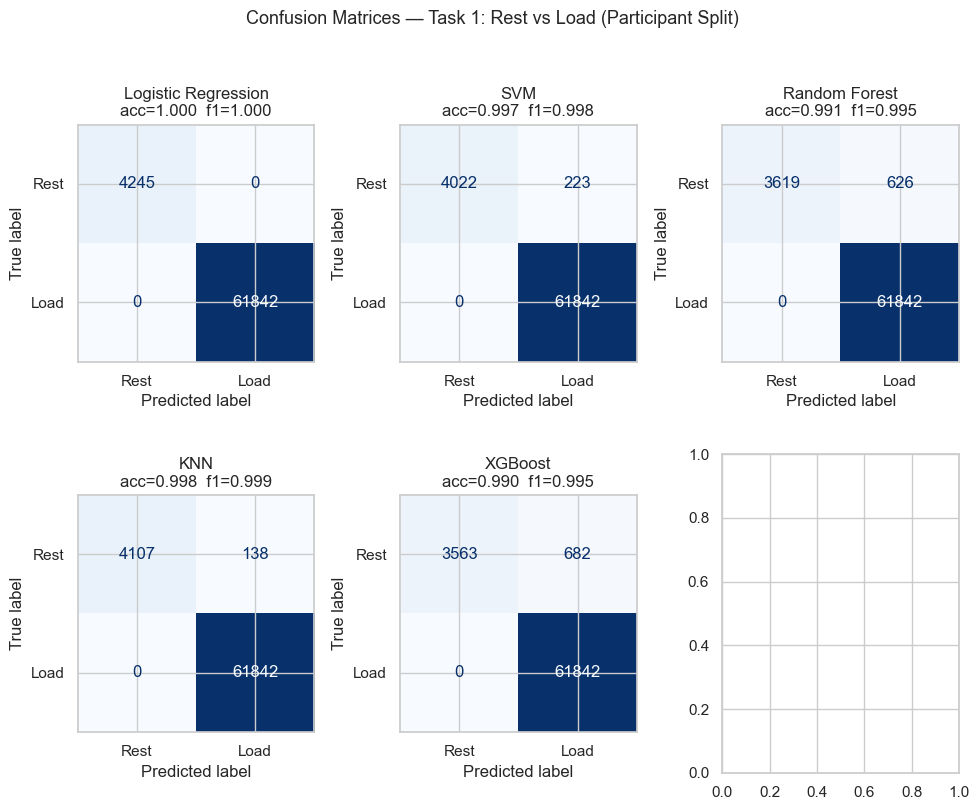

Saved: results/participant_split/ps_confusion_matrix_rest_vs_load.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for ax, (name, r) in zip(axes.flatten(), results_t1.items()):
    cm = confusion_matrix(y_te1, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Rest', 'Load']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}")

plt.suptitle('Confusion Matrices — Task 1: Rest vs Load (Participant Split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'ps_confusion_matrix_rest_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/participant_split/ps_confusion_matrix_rest_vs_load.png')

## 7. Task 2 — WM vs VA

This is the harder binary task and the one benchmarked in Jin et al. (2025).  
With a participant-level split the model cannot rely on person-specific patterns, so we expect results closer to the reported **SVM ~62% accuracy**.

In [11]:
print('Training Task 2 — WM vs VA ...')
results_t2 = {}
for name, model in get_models().items():
    print(f'  {name} ...', end=' ', flush=True)
    results_t2[name] = evaluate(model, X_tr2, y_tr2, X_te2, y_te2)
    print(f"acc={results_t2[name]['accuracy']:.4f}")

rows = [{'Model': n, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
         'Recall': r['recall'], 'F1': r['f1']} for n, r in results_t2.items()]
df_t2 = pd.DataFrame(rows).set_index('Model')
print('\nTask 2 Results:')
df_t2

Training Task 2 — WM vs VA ...
  Logistic Regression ... 

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


acc=0.7518
  SVM ... acc=0.7503
  Random Forest ... acc=0.7101
  KNN ... acc=0.7026
  XGBoost ... acc=0.6960

Task 2 Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.7518,0.7005,0.8798,0.7800
SVM,0.7503,0.6909,0.9063,0.7840
Random Forest,0.7101,0.6633,0.8536,0.7465
KNN,0.7026,0.6864,0.7464,0.7151
XGBoost,0.6960,0.6612,0.8040,0.7256


### Confusion Matrices — Task 2 (Participant Split)

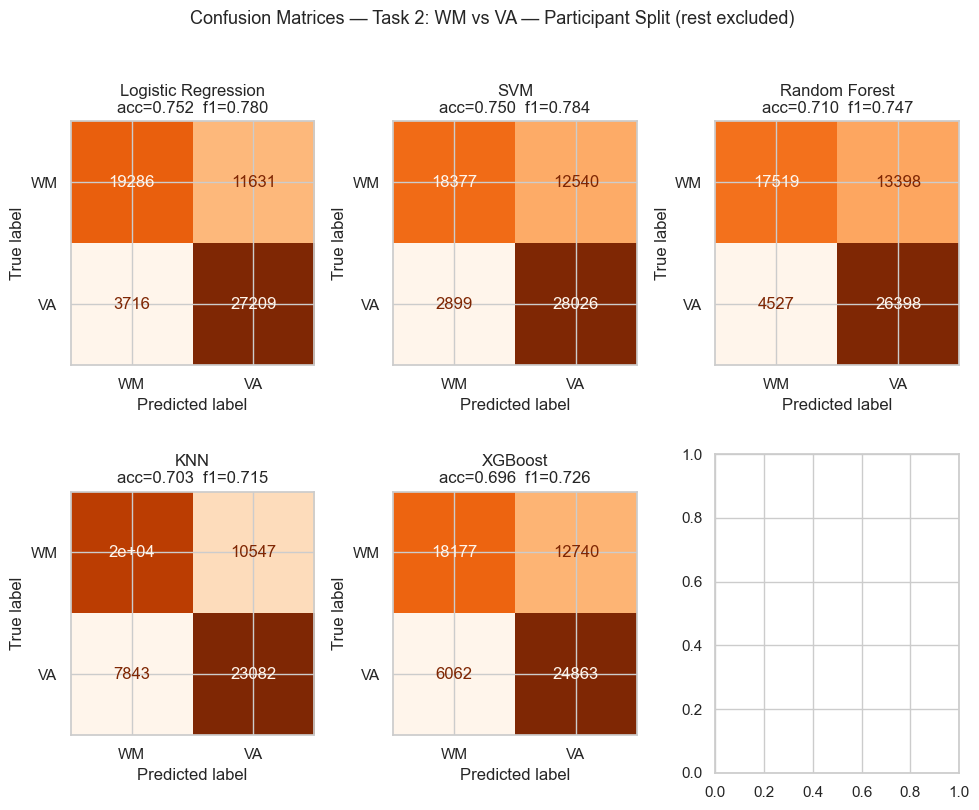

Saved: results/participant_split/ps_confusion_matrix_wm_vs_va.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for ax, (name, r) in zip(axes.flatten(), results_t2.items()):
    cm = confusion_matrix(y_te2, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['WM', 'VA']).plot(
        ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"{name}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}")

plt.suptitle('Confusion Matrices — Task 2: WM vs VA — Participant Split (rest excluded)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'ps_confusion_matrix_wm_vs_va.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/participant_split/ps_confusion_matrix_wm_vs_va.png')

## 8. Summary Results Table

Results saved to `results/participant_split/participant_split_results.csv`. The final cell also shows a side-by-side comparison with the time-based split results from notebook 02 to illustrate the performance gap between the two evaluation strategies.

In [13]:
rows_all = []
for task_name, results in [('Rest vs Load', results_t1), ('WM vs VA', results_t2)]:
    for model_name, r in results.items():
        rows_all.append({
            'Task': task_name, 'Model': model_name,
            'Accuracy': r['accuracy'], 'Precision': r['precision'],
            'Recall': r['recall'], 'F1': r['f1'],
        })

df_ps = pd.DataFrame(rows_all)
df_ps.to_csv(RESULTS / 'participant_split_results.csv', index=False)
print('Saved: results/participant_split/participant_split_results.csv\n')
print(df_ps.to_string(index=False))

svm_t2 = results_t2['SVM']['accuracy']
print(f'\nSVM accuracy on WM vs VA (participant split): {svm_t2*100:.1f}%')
print(f'Jin et al. (2025) target:                      ~62.0%')
print(f'Difference:                                    {svm_t2*100 - 62.0:+.1f} pp')

Saved: results/participant_split/participant_split_results.csv

        Task               Model  Accuracy  Precision  Recall     F1
Rest vs Load Logistic Regression    1.0000     1.0000  1.0000 1.0000
Rest vs Load                 SVM    0.9966     0.9964  1.0000 0.9982
Rest vs Load       Random Forest    0.9905     0.9900  1.0000 0.9950
Rest vs Load                 KNN    0.9979     0.9978  1.0000 0.9989
Rest vs Load             XGBoost    0.9897     0.9891  1.0000 0.9945
    WM vs VA Logistic Regression    0.7518     0.7005  0.8798 0.7800
    WM vs VA                 SVM    0.7503     0.6909  0.9063 0.7840
    WM vs VA       Random Forest    0.7101     0.6633  0.8536 0.7465
    WM vs VA                 KNN    0.7026     0.6864  0.7464 0.7151
    WM vs VA             XGBoost    0.6960     0.6612  0.8040 0.7256

SVM accuracy on WM vs VA (participant split): 75.0%
Jin et al. (2025) target:                      ~62.0%
Difference:                                    +13.0 pp


## 9. Comparison: Time-Based Split vs Participant Split

Loading the time-based results from notebook 02 and comparing side by side.
The gap between the two rows for each model quantifies **how much the model was relying on person-specific patterns** rather than truly generalising across subjects.

In [14]:
import os
tb_path = Path('../results/baselines/baseline_results.csv')
if os.path.exists(tb_path):
    df_tb = pd.read_csv(tb_path)
    df_tb['Split'] = 'Time-based'
    df_ps2 = df_ps.copy()
    df_ps2['Split'] = 'Participant'
    df_cmp = pd.concat([df_tb, df_ps2], ignore_index=True)
    df_cmp = df_cmp.pivot_table(
        index=['Task', 'Model'], columns='Split', values='Accuracy'
    ).reset_index()
    df_cmp['Drop (pp)'] = ((df_cmp['Time-based'] - df_cmp['Participant']) * 100).round(1)
    print('Accuracy comparison (time-based vs participant split):')
    print(df_cmp.to_string(index=False))
else:
    print('baseline_results.csv not found — run 02_baselines.ipynb first.')

Accuracy comparison (time-based vs participant split):
        Task               Model  Participant  Time-based  Drop (pp)
Rest vs Load                 KNN       0.9979      0.9800       -1.8
Rest vs Load Logistic Regression       1.0000      0.9952       -0.5
Rest vs Load       Random Forest       0.9905      0.9810       -1.0
Rest vs Load                 SVM       0.9966      0.9944       -0.2
Rest vs Load             XGBoost       0.9897      0.9759       -1.4
    WM vs VA                 KNN       0.7026      0.8011        9.9
    WM vs VA Logistic Regression       0.7518      0.8666       11.5
    WM vs VA       Random Forest       0.7101      0.8676       15.8
    WM vs VA                 SVM       0.7503      0.8567       10.6
    WM vs VA             XGBoost       0.6960      0.8542       15.8


## Summary

- **Participant-level split**: 17 train / 4 test participants (`random_state=42` for reproducibility).
- **No data leakage**: scaler fitted only on training participants.
- Results saved to `results/participant_split/participant_split_results.csv`.
- Confusion matrices saved as `results/participant_split/ps_confusion_matrix_rest_vs_load.png` and `results/participant_split/ps_confusion_matrix_wm_vs_va.png`.
- Comparison table shows the accuracy drop from the time-based split — this gap is the cost of true cross-subject generalisation.

Next step: feature importance analysis and model improvement.

# Feature Importance and Model Interpretability

## SHAP (SHapley Additive exPlanations): for tree based classifiers (Random Forest, XGBoost)

This script trains an XGBoost model on Task 2 (WM vs VA), calculates the SHAP values using the test set participants, and generates three essential diagnostic plots.

Computing SHAP values for XGBoost on Task 2 (WM vs VA)...


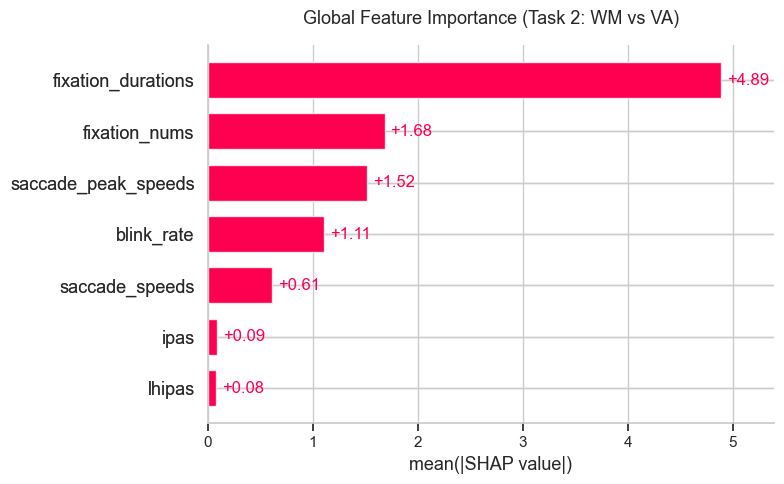

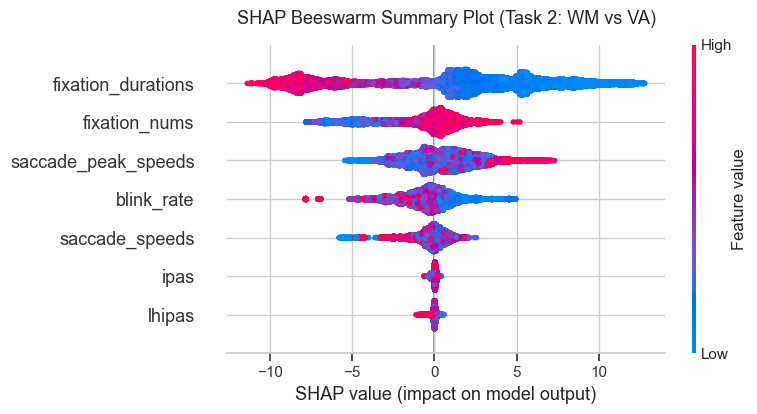

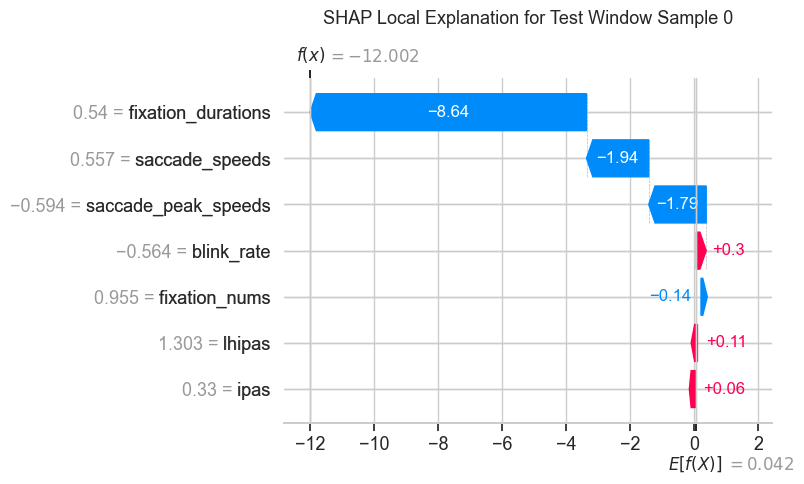

SHAP analysis complete. Plots saved to: ..\results\participant_split


In [16]:
## 5. Feature Importance via SHAP Analysis
import shap
import pandas as pd
import matplotlib.pyplot as plt

print("Computing SHAP values for XGBoost on Task 2 (WM vs VA)...")

# 1. Re-train the XGBoost model on Task 2 data
xgb_model = XGBClassifier(n_estimators=200, n_jobs=-1, eval_metric='logloss', random_state=42, verbosity=0)
xgb_model.fit(X_tr2, y_tr2)

# 2. Convert the standardized test features to a DataFrame so plots show the actual feature names
X_te2_df = pd.DataFrame(X_te2, columns=FEATURES)

# 3. Initialize the TreeExplainer (optimized for tree models like XGBoost and Random Forest)
explainer = shap.TreeExplainer(xgb_model)

# 4. Compute SHAP values for the test set participants
shap_values = explainer(X_te2_df)
# Note: depends on your SHAP version, explainer(X_te2_df) returns a rich Explanation object

# 5. Plot 1: Global Feature Importance Bar Plot
# Shows the average magnitude of change each feature introduces to the model's prediction
plt.figure(figsize=(9, 5))
shap.plots.bar(shap_values, show=False)
plt.title("Global Feature Importance (Task 2: WM vs VA)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(RESULTS / 'shap_bar_wm_vs_va.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Plot 2: Summary Beeswarm Plot
# Shows both feature importance and the direction of the effect (e.g., does higher pupil size increase or decrease VA prediction?)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Beeswarm Summary Plot (Task 2: WM vs VA)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(RESULTS / 'shap_beeswarm_wm_vs_va.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. Plot 3: Local Explanation (Waterfall Plot for the first test instance)
# Explains exactly why the model made a specific prediction for an individual data window
plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Local Explanation for Test Window Sample 0", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(RESULTS / 'shap_waterfall_sample0.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"SHAP analysis complete. Plots saved to: {RESULTS}")

## For Linear Models (Logistic Regression & SVM): Model Coefficients 
## For Distance-Based Models (KNN): Permutation Feature Importance

Calculate and plot feature importances for all three non-tree models on Task 2 (WM vs VA).

Calculating feature importances for non-tree models...


c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


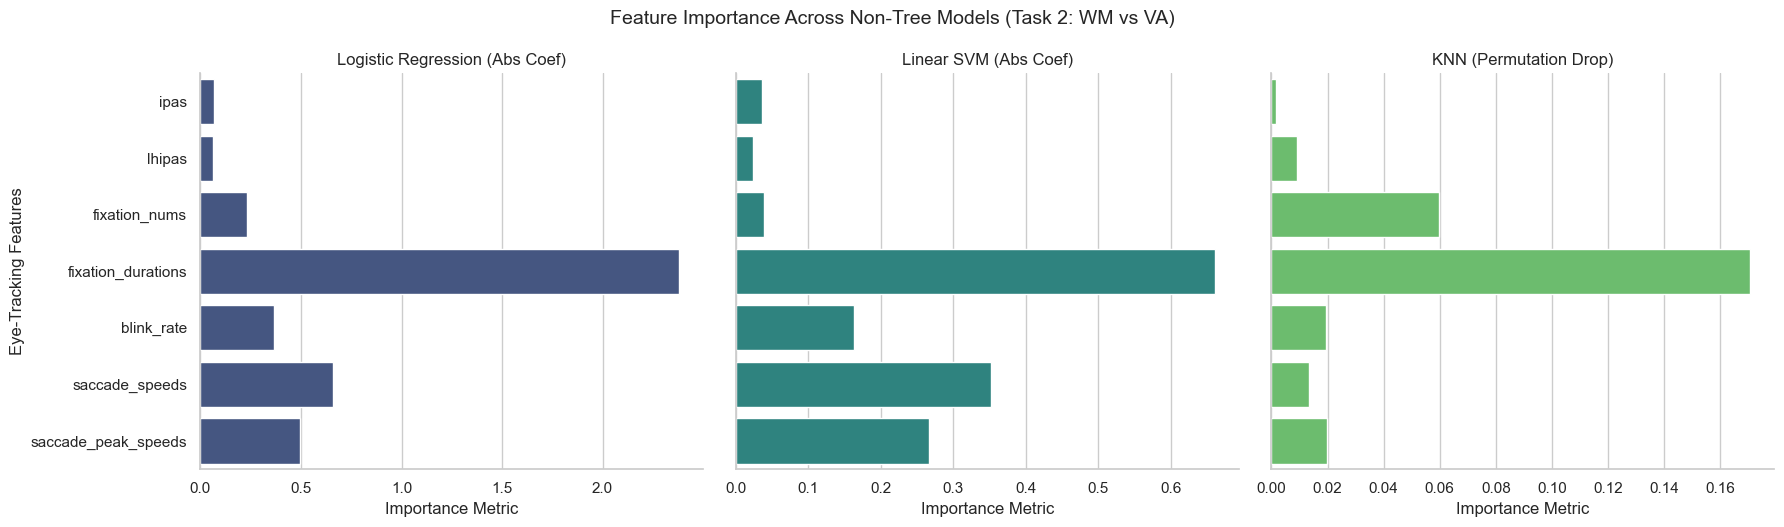

Analysis complete. Importance comparison plot saved to ..\results\participant_split\non_tree_feature_importances.png


In [17]:
## 6. Feature Importance for Non-Tree Models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

print("Calculating feature importances for non-tree models...")

# 1. Fit the non-tree models on Task 2
lr_model = LogisticRegression(max_iter=5000, class_weight='balanced', n_jobs=-1, random_state=42).fit(X_tr2, y_tr2)
svm_model = LinearSVC(C=1.0, max_iter=3000, random_state=42).fit(X_tr2, y_tr2)
knn_model = KNeighborsClassifier(n_neighbors=11, n_jobs=-1).fit(X_tr2, y_tr2)

# 2. Extract Absolute Coefficients for Logistic Regression and SVM
lr_importance = np.abs(lr_model.coef_[0])
svm_importance = np.abs(svm_model.coef_[0])

# 3. Compute Permutation Importance for KNN (using the test set)
knn_result = permutation_importance(
    knn_model, X_te2, y_te2, n_repeats=10, random_state=42, n_jobs=-1
)
knn_importance = knn_result.importances_mean

# 4. Consolidate into a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Logistic Regression (Abs Coef)': lr_importance,
    'Linear SVM (Abs Coef)': svm_importance,
    'KNN (Permutation Drop)': knn_importance
})

# Melt the dataframe to make it compatible with seaborn catplot/barplot
melted_df = importance_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')

# 5. Plot the importances side-by-side
g = sns.catplot(
    data=melted_df, x='Importance', y='Feature', hue='Model',
    kind='bar', col='Model', col_wrap=3, sharex=False, height=5, aspect=1.2,
    palette='viridis', legend=False
)

# Clean up titles and layouts
g.set_titles("{col_name}")
g.set_axis_labels("Importance Metric", "Eye-Tracking Features")
plt.suptitle("Feature Importance Across Non-Tree Models (Task 2: WM vs VA)", fontsize=14, y=1.05)

# Save the plot
plt.savefig(RESULTS / 'non_tree_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Analysis complete. Importance comparison plot saved to {RESULTS / 'non_tree_feature_importances.png'}")